# LSTM Multi-Sensor Forecasting — Improved

**Note on "accuracy":** this is a *regression* task (predicting continuous sensor values), so classification accuracy doesn't apply here. Keras won't compute it, and if you ever see `accuracy: 1.0000` on a regression model it's a bug, not a good sign. The regression equivalent of "accuracy" is **R²** (bounded, easy to read, higher = better) — added below as a custom metric so you get `r2` / `val_r2` printed every epoch right next to `loss` / `val_loss`, and plotted train-vs-validation after training.

Other changes made in this pass (see inline comments):
- Custom Keras `r2_keras` metric → train/val R² per epoch + curves
- `Huber` loss instead of raw MSE (more robust to the outlier-heavy sensor readings implied by your ~60% MAPE on `GA0151_A`)
- `recurrent_dropout` + `clipnorm` on the LSTM layers for better regularization/stability
- `ReduceLROnPlateau` so the LR backs off automatically when `val_loss` stalls, instead of relying on early stopping alone
- Loss/MAE/R² curves plotted (train vs val) right after training
- A results table + actual-vs-predicted plot at the end instead of only printed numbers
- Minor cleanup (removed a redundant reshape, used `Path` for the model file)

Outputs are cleared since I don't have your `feature_engineered.csv` to re-run it — re-run all cells top to bottom.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras import backend as K
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
DATA_PATH = "../../dataset/processed/feature_engineered.csv"
SEQ_LENGTH = 24
FORECAST_HORIZON = 6
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
BATCH_SIZE = 64
EPOCH = 100
PATIENCE = 10          # early stopping patience
LR_PATIENCE = 5         # ReduceLROnPlateau patience
INITIAL_LR = 1e-3

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (33476, 65)


In [5]:
df = df.select_dtypes(include=[np.number])

In [6]:
TARGET_COLUMNS = [
    "GA0151_A",
    "GA0151_C",
    "GA0151_D"
]

In [7]:
feature_columns = df.columns.tolist()
print("Number of features:", len(feature_columns))

Number of features: 65


In [8]:
# Chronological split — no shuffling, since this is time series (unchanged, this was already correct)
n = len(df)
train_end = int(n * TRAIN_RATIO)
val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Total samples :", len(df))
print("Training      :", len(train_df))
print("Validation    :", len(val_df))
print("Testing       :", len(test_df))

Total samples : 33476
Training      : 23433
Validation    : 5021
Testing       : 5022


In [9]:
# Fit scaler on TRAIN ONLY to avoid leakage (unchanged, this was already correct)
scaler = MinMaxScaler()
scaler.fit(train_df[feature_columns])
train_scaled = scaler.transform(train_df[feature_columns])
val_scaled = scaler.transform(val_df[feature_columns])
test_scaled = scaler.transform(test_df[feature_columns])

In [10]:
joblib.dump(scaler, "traffic_scaler.pkl")

['traffic_scaler.pkl']

In [11]:
def create_sequences(data, target_indices, seq_length, forecast_horizon):
    X = []
    y = []

    for i in range(seq_length, len(data) - forecast_horizon + 1):

        # Past 24 hours
        X.append(data[i - seq_length:i])

        # Next 6 hours for target sensors
        y.append(
            data[
                i:i + forecast_horizon,
                target_indices
            ]
        )

    return np.array(X), np.array(y)

In [12]:
target_indices = [
    feature_columns.index(col)
    for col in TARGET_COLUMNS
]

In [13]:
# Create training sequences
X_train, y_train = create_sequences(train_scaled, target_indices, SEQ_LENGTH, FORECAST_HORIZON)

# Create validation sequences
X_val, y_val = create_sequences(val_scaled, target_indices, SEQ_LENGTH, FORECAST_HORIZON)

# Create testing sequences
X_test, y_test = create_sequences(test_scaled, target_indices, SEQ_LENGTH, FORECAST_HORIZON)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (23404, 24, 65)
y_train: (23404, 6, 3)
X_val  : (4992, 24, 65)
y_val  : (4992, 6, 3)
X_test : (4993, 24, 65)
y_test : (4993, 6, 3)


In [14]:
# Flatten the (horizon, n_targets) window into a single output vector for the Dense head
y_train = y_train.reshape(y_train.shape[0], FORECAST_HORIZON * len(TARGET_COLUMNS))
y_val = y_val.reshape(y_val.shape[0], FORECAST_HORIZON * len(TARGET_COLUMNS))
y_test = y_test.reshape(y_test.shape[0], FORECAST_HORIZON * len(TARGET_COLUMNS))

print("After reshaping:")
print("y_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

After reshaping:
y_train: (23404, 18)
y_val  : (4992, 18)
y_test : (4993, 18)


## Custom R² metric (the "accuracy" for regression)

R² is bounded (≤ 1, higher is better, 0 ≈ "no better than predicting the mean") so it reads like an accuracy score during training. Keras metrics must be differentiable ops on tensors, so this is implemented with `keras.backend` rather than `sklearn.r2_score` (which only works on numpy arrays after training).

In [15]:
def r2_keras(y_true, y_pred):
    ss_res = K.sum(K.square(y_true - y_pred))
    ss_tot = K.sum(K.square(y_true - K.mean(y_true)))
    return 1 - ss_res / (ss_tot + K.epsilon())

In [16]:
model = Sequential([
    Input(shape=(SEQ_LENGTH, len(feature_columns))),

    # recurrent_dropout adds regularization inside the recurrent connections themselves,
    # which plain Dropout (between layers) doesn't cover
    LSTM(128, return_sequences=True, recurrent_dropout=0.1),
    Dropout(0.2),

    LSTM(64, return_sequences=False, recurrent_dropout=0.1),
    Dropout(0.2),

    Dense(64, activation="relu"),

    Dense(FORECAST_HORIZON * len(TARGET_COLUMNS))
])

In [17]:
model.compile(
    # clipnorm guards against exploding gradients, which recurrent_dropout + LSTMs can be prone to
    optimizer=Adam(learning_rate=INITIAL_LR, clipnorm=1.0),
    # Huber is quadratic near zero and linear for large errors, so a handful of outlier readings
    # (spikes in sensor data) won't dominate the loss the way plain MSE would
    loss="huber",
    metrics=["mae", r2_keras]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        99,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,066 (601.82 KB)

 Trainable params: 154,066 (601.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "lstm_model.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min"
)

# Backs the learning rate off when val_loss plateaus, instead of only stopping outright
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=LR_PATIENCE,
    min_lr=1e-6,
    verbose=1
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCH,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)

Epoch 1/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - loss: 0.0051 - mae: 0.0690 - r2_keras: 0.6965 - val_loss: 0.0044 - val_mae: 0.0652 - val_r2_keras: 0.7942 - learning_rate: 0.0010
Epoch 2/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0030 - mae: 0.0523 - r2_keras: 0.8224 - val_loss: 0.0038 - val_mae: 0.0573 - val_r2_keras: 0.8178 - learning_rate: 0.0010
Epoch 3/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - loss: 0.0026 - mae: 0.0486 - r2_keras: 0.8433 - val_loss: 0.0037 - val_mae: 0.0564 - val_r2_keras: 0.8245 - learning_rate: 0.0010
Epoch 4/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0024 - mae: 0.0463 - r2_keras: 0.8559 - val_loss: 0.0038 - val_mae: 0.0574 - val_r2_keras: 0.8201 - learning_rate: 0.0010
Epoch 5/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0023 - mae: 0.0448 - r2_keras: 0.8636 - val_loss: 0.0033 - val_mae: 0.0556 - val_r2_keras: 0.8419 - learning_rate: 0.0010
Epoch 6/100
366/366 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - loss: 0.0022 

## Training curves: loss, MAE, and R² (train vs. validation)

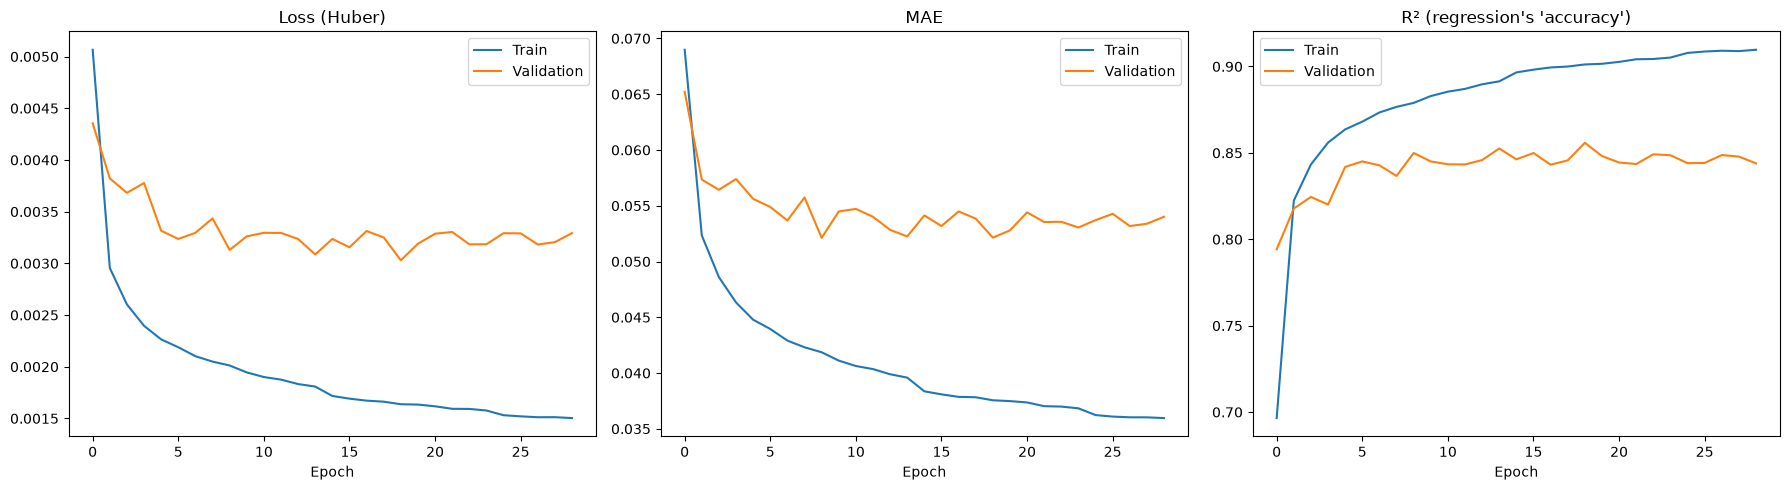

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history["loss"], label="Train")
axes[0].plot(history.history["val_loss"], label="Validation")
axes[0].set_title("Loss (Huber)")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["mae"], label="Train")
axes[1].plot(history.history["val_mae"], label="Validation")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].legend()

axes[2].plot(history.history["r2_keras"], label="Train")
axes[2].plot(history.history["val_r2_keras"], label="Validation")
axes[2].set_title("R² (regression's 'accuracy')")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

In [21]:
test_loss, test_mae, test_r2 = model.evaluate(X_test, y_test, verbose=1)

print("\nTest Loss (Huber):", test_loss)
print("Test MAE:", test_mae)
print("Test R\u00b2:", test_r2)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0040 - mae: 0.0621 - r2_keras: 0.8372

Test Loss (Huber): 0.004043900407850742
Test MAE: 0.062051642686128616
Test R²: 0.8371859192848206


In [22]:
y_pred = model.predict(X_test)
print("\nPrediction shape:")
print("y_pred:", y_pred.shape)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Prediction shape:
y_pred: (4993, 18)


In [23]:
y_pred = y_pred.reshape(-1, FORECAST_HORIZON, len(TARGET_COLUMNS))
y_test_original = y_test.reshape(-1, FORECAST_HORIZON, len(TARGET_COLUMNS))

print("\nFinal shapes:")
print("y_pred:", y_pred.shape)
print("y_test:", y_test_original.shape)


Final shapes:
y_pred: (4993, 6, 3)
y_test: (4993, 6, 3)


In [24]:
num_features = len(feature_columns)

y_pred_original = np.zeros((y_pred.shape[0], FORECAST_HORIZON, num_features))
y_test_original_scaled = np.zeros((y_test_original.shape[0], FORECAST_HORIZON, num_features))

for j, target_idx in enumerate(target_indices):
    y_pred_original[:, :, target_idx] = y_pred[:, :, j]
    y_test_original_scaled[:, :, target_idx] = y_test_original[:, :, j]

# Inverse scaling
y_pred_original = scaler.inverse_transform(
    y_pred_original.reshape(-1, num_features)
).reshape(-1, FORECAST_HORIZON, num_features)

y_test_original = scaler.inverse_transform(
    y_test_original_scaled.reshape(-1, num_features)
).reshape(-1, FORECAST_HORIZON, num_features)

y_pred_original = y_pred_original[:, :, target_indices]
y_test_original = y_test_original[:, :, target_indices]

print("\nOriginal-scale shapes:")
print("Predictions:", y_pred_original.shape)
print("Actual     :", y_test_original.shape)


Original-scale shapes:
Predictions: (4993, 6, 3)
Actual     : (4993, 6, 3)


## Per-sensor metrics (as a table, and plotted)

In [25]:
results = []

for i, sensor in enumerate(TARGET_COLUMNS):
    actual = y_test_original[:, :, i].flatten()
    predicted = y_pred_original[:, :, i].flatten()

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    results.append({"Sensor": sensor, "MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2": r2})

results_df = pd.DataFrame(results).set_index("Sensor")
results_df

,MAE,RMSE,MAPE (%),R2
Sensor,,,,
GA0151_A,9.621049,15.559898,64.278955,0.638942
GA0151_C,24.406333,33.479600,21.727838,0.804057
GA0151_D,22.735762,30.749625,33.522624,0.734875


`GA0151_A` had the weakest fit last run (R² ≈ 0.64, MAPE ≈ 60%) compared to the other two sensors. That's usually a sign that sensor's values sit closer to zero (so MAPE explodes on small denominators) and/or it's noisier — worth checking its distribution separately rather than assuming the model is failing across the board.

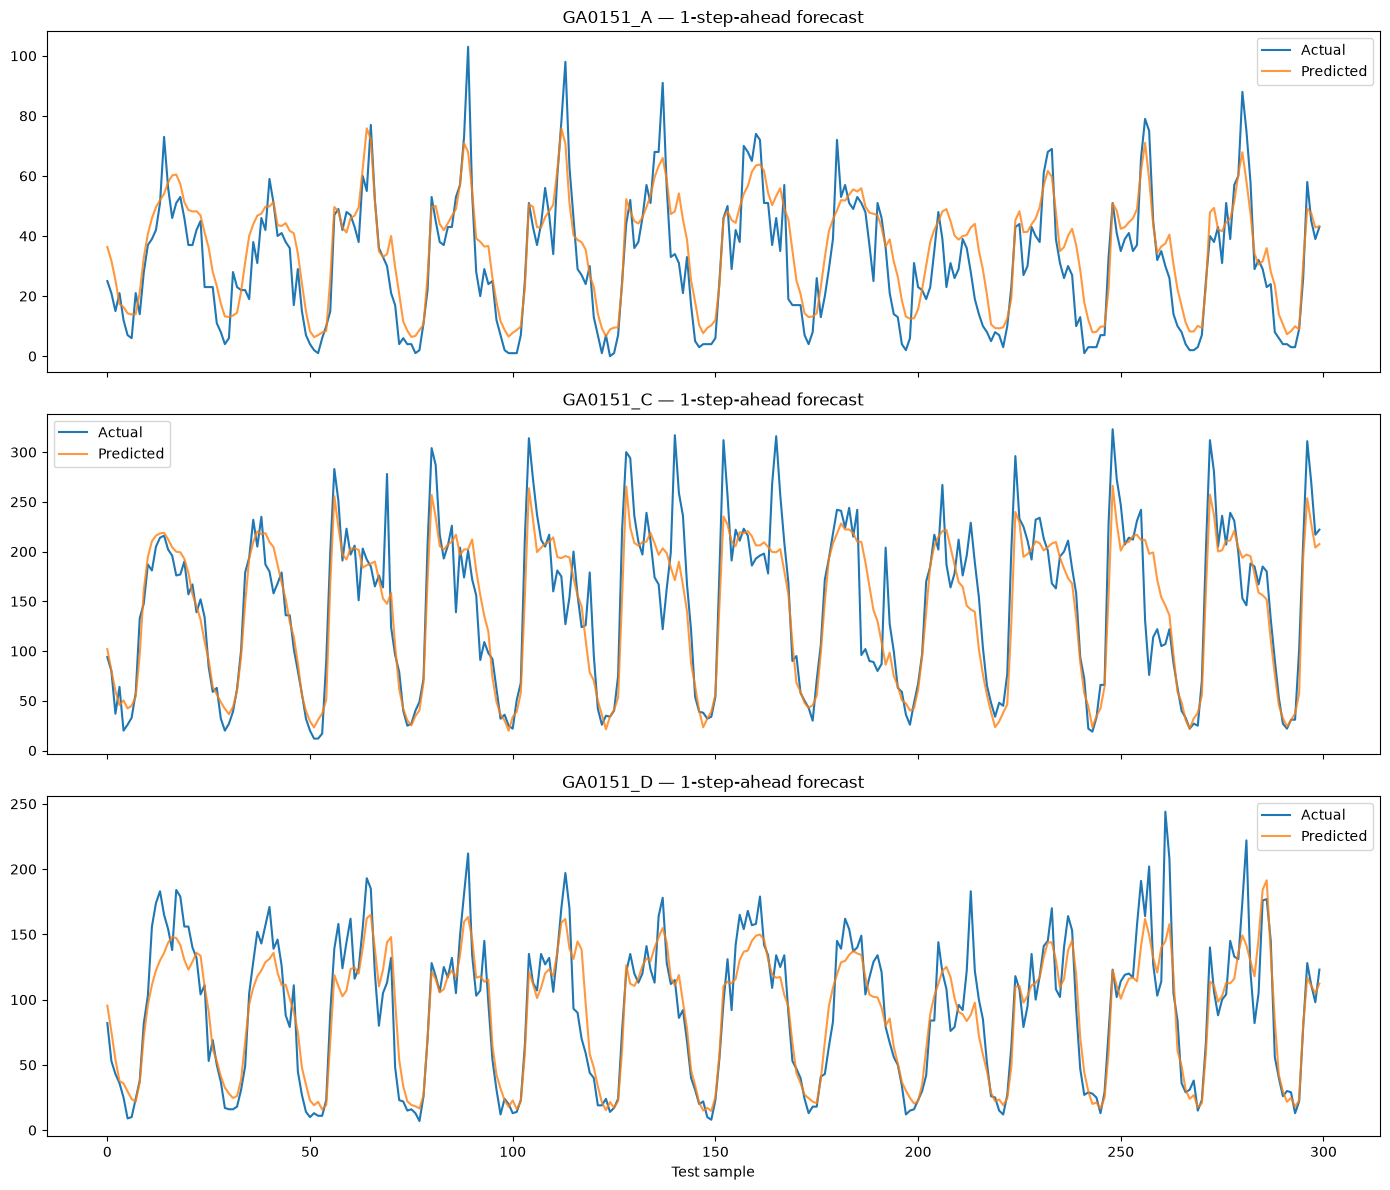

In [26]:
# Actual vs. predicted for the first forecast step of each sensor, over a slice of the test set
fig, axes = plt.subplots(len(TARGET_COLUMNS), 1, figsize=(14, 4 * len(TARGET_COLUMNS)), sharex=True)
window = slice(0, 300)  # first 300 test sequences

for i, sensor in enumerate(TARGET_COLUMNS):
    ax = axes[i]
    ax.plot(y_test_original[window, 0, i], label="Actual", linewidth=1.5)
    ax.plot(y_pred_original[window, 0, i], label="Predicted", linewidth=1.5, alpha=0.8)
    ax.set_title(f"{sensor} — 1-step-ahead forecast")
    ax.legend()

plt.xlabel("Test sample")
plt.tight_layout()
plt.show()